# ATUS-Based "Sun Clock"

**Goal:** use the American Time Use Survey (ATUS) activity data to build a
time-of-day curve of how likely people are to be **away from home**, and use
it to drive the "Sun Clock": a clock that rings at a **fixed, constant rate**
(e.g. every 2 hours on average), and each time it rings, an at-home agent's
**probability of leaving** is modified.

**Pipeline**
1. Load the raw ATUS **Activity file** (one row per activity, per
   respondent-day).
2. Flag each activity as *at home* vs *away from home* using `TEWHERE`.
3. Compute, for every hour of the day, the (weighted) fraction of
   person-time spent away from home.
4. Turn that curve into a **leave-probability** for each hour (0 to
   `BASE_LEAVE_PROB`), independent of the ring rate.
5. Sample ring times from a **constant-rate (homogeneous) Poisson process**.
6. On each ring, roll the dice on whether the agent leaves, using the
   probability for that hour.

In [10]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


## 1. Configuration

Key ATUS variables, for reference:

| logical field | column in this file | meaning |
|---|---|---|
| respondent/day id | `TUCASEID ` | unique per respondent-day |
| activity order | `TUACTIVITY_N` | sequence number within the day |
| location | `TEWHERE` | `1` = respondent's home or yard; other codes = away; `-1` = "out of universe" (location wasn't asked); `-2`/`-3` = don't know / refused |
| start time | `TUSTARTTIM` | `HH:MM:SS`, wall-clock time |
| stop time | `TUSTOPTIME` | `HH:MM:SS`, wall-clock time — can be *less than* the start time when an activity crosses midnight (the ATUS diary day runs 4:00am to 4:00am, not midnight to midnight) |

`missing_codes` contains don't-know/refused codes  — `-2, -3`

In [11]:
DATA_PATH = "C:/Users/amyyy/Downloads/atusact-2025/atusact_2025.dat" 

CONFIG = {
    "id_col":     "TUCASEID",
    "seq_col":    "TUACTIVITY_N",
    "where_col":  "TEWHERE",
    "start_col":  "TUSTARTTIM",
    "stop_col":   "TUSTOPTIME",
    "weight_col": "TUFINLWGT",             
    "home_codes": [1],              # TEWHERE code(s) meaning "at home"
    "missing_codes": [-2, -3],     
}

N_MINUTES_PER_DAY = 1440


## 2. Loading the ATUS Activity file

Two ATUS-specific quirks need explicit handling, both of which
disproportionately affect the overnight hours if ignored:

1. **`TEWHERE == -1` means "not asked."** BLS does not collect
   location for activities like sleeping and grooming. These are recorded
   as `-1` ("out of universe"). Since sleeping
   overwhelmingly happens at home, we recode `-1` to the home code rather
   than dropping those rows. Dropping them would delete the single largest
   block of overnight at-home time from the data.
2. **Activities that cross midnight are recorded with `stop < start`,** since
   the ATUS diary day runs 4:00am-to-4:00am with plain wall-clock times
   Rather than dropping these rows, we split them into two segments: one running to
   midnight, one running from midnight to the stop time.

Both quirks concentrate in the same place (the overnight sleep block), so
skipping either one biases the "fraction away from home" estimate upward
for the pre-dawn hours.


In [12]:
def _sniff_delimiter(path, sample_bytes=8192):
    with open(path, "r", errors="ignore") as f:
        sample = f.read(sample_bytes)
    try:
        return csv.Sniffer().sniff(sample, delimiters=",|\t;").delimiter
    except Exception:
        return ","


def _parse_time_to_minutes(value):
    """Accepts 'HH:MM:SS', 'HH:MM', or an already-numeric value (minutes)."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    s = str(value).strip()
    parts = s.split(":")
    if len(parts) == 1:
        return float(parts[0])
    h = int(parts[0])
    m = int(parts[1]) if len(parts) > 1 else 0
    sec = int(parts[2]) if len(parts) > 2 else 0
    return h * 60 + m + sec / 60.0


def load_atus_activity_file(path, config=CONFIG):
    sep = _sniff_delimiter(path)
    df = pd.read_csv(path, sep=sep, engine="python")
    df.columns = [c.strip() for c in df.columns]
    colmap = {c.upper(): c for c in df.columns}

    def resolve(logical_key, required=True):
        wanted = config[logical_key]
        if wanted is None:
            return None
        actual = colmap.get(str(wanted).upper())
        if actual is None and required:
            raise ValueError(
                f"Column '{wanted}' (for '{logical_key}') not found. "
                f"Columns in file: {list(df.columns)}. "
                f"Update CONFIG['{logical_key}'] to match your file."
            )
        return actual

    id_col    = resolve("id_col")
    seq_col   = resolve("seq_col")
    where_col = resolve("where_col")
    start_col = resolve("start_col")
    stop_col  = resolve("stop_col")
    weight_col = resolve("weight_col", required=False)

    out = pd.DataFrame({
        "TUCASEID": df[id_col],
        "TUACTIVITY_N": df[seq_col],
        "TEWHERE": pd.to_numeric(df[where_col], errors="coerce"),
        "start_min": df[start_col].map(_parse_time_to_minutes),
        "end_min": df[stop_col].map(_parse_time_to_minutes),
    })
    out["weight"] = (
        pd.to_numeric(df[weight_col], errors="coerce").fillna(0.0)
        if weight_col is not None else 1.0
    )

    # TEWHERE == -1: location not asked (sleeping/grooming) -- recode to home
    # rather than dropping, since these activities happen at home.
    out["TEWHERE"] = out["TEWHERE"].replace(-1, config["home_codes"][0])

    # only genuine don't-know/refused codes get dropped now
    out = out[~out["TEWHERE"].isin(config["missing_codes"])].copy()
    out["away"] = ~out["TEWHERE"].isin(config["home_codes"])

    # clip to a single 24h diary day for binning purposes
    out["start_min"] = out["start_min"].clip(lower=0, upper=N_MINUTES_PER_DAY)
    out["end_min"] = out["end_min"].clip(lower=0, upper=N_MINUTES_PER_DAY)

    # activities crossing midnight (stop < start, e.g. overnight sleep) get
    # split into two segments instead of dropped.
    wraps = out["end_min"] <= out["start_min"]
    non_wrap = out[~wraps].copy()

    part1 = out[wraps].copy()
    part1["end_min"] = N_MINUTES_PER_DAY          # start_min -> midnight

    part2 = out[wraps].copy()
    part2["start_min"] = 0                        # midnight -> end_min

    out = pd.concat([non_wrap, part1, part2], ignore_index=True)
    out = out[out["end_min"] > out["start_min"]]  # drop genuine zero-length remnants
    return out.reset_index(drop=True)


def make_synthetic_atus(n_people=3000, seed=0):
    """Fallback demo data with a realistic daily away-from-home pattern,
    used only when DATA_PATH isn't found -- lets the rest of the notebook
    run end-to-end before you plug in the real ATUS extract."""
    r = np.random.default_rng(seed)

    def p_away(minute):
        hour = (minute / 60) % 24
        return (0.05
                + 0.50 * np.exp(-0.5 * ((hour - 14) / 4) ** 2)
                + 0.15 * np.exp(-0.5 * ((hour - 9) / 2) ** 2))

    rows = []
    for pid in range(n_people):
        t, seq = 0, 0
        while t < N_MINUTES_PER_DAY:
            seq += 1
            away = r.random() < p_away(t)
            dur = max(5, int(r.exponential(45)))
            end = min(N_MINUTES_PER_DAY, t + dur)
            rows.append({
                "TUCASEID": pid, "TUACTIVITY_N": seq,
                "TEWHERE": 1 if not away else int(r.choice([2, 6, 7, 9, 11])),
                "start_min": t, "end_min": end, "weight": 1.0,
            })
            t = end
    df = pd.DataFrame(rows)
    df["away"] = ~df["TEWHERE"].isin(CONFIG["home_codes"])
    return df


try:
    activity_df = load_atus_activity_file(DATA_PATH)
    print(f"Loaded {len(activity_df):,} activity records from {DATA_PATH}")
except FileNotFoundError:
    print(f"'{DATA_PATH}' not found -- using synthetic demo data instead. "
          f"Point DATA_PATH at your real .dat file when you have it.")
    activity_df = make_synthetic_atus()

activity_df.head()


Loaded 119,843 activity records from C:/Users/amyyy/Downloads/atusact-2025/atusact_2025.dat


,TUCASEID,TUACTIVITY_N,TEWHERE,start_min,end_min,weight,away
0,20250101250011,1,1,240.0,450.0,1.0,False
1,20250101250011,2,1,450.0,480.0,1.0,False
2,20250101250011,3,1,480.0,510.0,1.0,False
3,20250101250011,4,12,510.0,515.0,1.0,True
4,20250101250011,5,2,515.0,560.0,1.0,True


## 3. Daily "away from home" curve

For every minute of the day we add up (weighted) person-time using a
sweep-line / difference-array trick: `+weight` at an activity's start
minute, `-weight` at its end minute, then a cumulative sum recovers, at
every minute, how much weighted person-time is "in progress." Doing this
once for *all* activities (denominator) and once for *away* activities only
(numerator) gives the fraction of people away from home at each minute —
then we bin that to hours.


In [22]:
def sweep_accumulate(df, n_minutes=N_MINUTES_PER_DAY):
    delta = np.zeros(n_minutes + 1)
    s = df["start_min"].to_numpy(dtype=int)
    e = df["end_min"].to_numpy(dtype=int)
    w = df["weight"].to_numpy(dtype=float)
    np.add.at(delta, s, w)
    np.add.at(delta, e, -w)
    return np.cumsum(delta)[:n_minutes]


total_by_min = sweep_accumulate(activity_df)
away_by_min = sweep_accumulate(activity_df[activity_df["away"]])
home_by_min = total_by_min - away_by_min
frac_away_by_min = np.divide(
    away_by_min, total_by_min,
    out=np.zeros_like(away_by_min), where=total_by_min > 0,
)

hours = np.arange(24)
frac_away_hour = np.array([
    away_by_min[h*60:(h+1)*60].sum() / total_by_min[h*60:(h+1)*60].sum()
    for h in hours
])

# Count observed home -> away and away -> home activity transitions by hour.
ordered = activity_df.sort_values(
    ["TUCASEID", "start_min", "end_min", "TUACTIVITY_N"]
).copy()
ordered["previous_away"] = ordered.groupby("TUCASEID")["away"].shift()
previous_away = ordered["previous_away"].fillna(False).astype(bool)
valid_transition = ordered["previous_away"].notna()
leave_events = ordered[valid_transition & ordered["away"] & ~previous_away]
return_events = ordered[valid_transition & ~ordered["away"] & previous_away]

leave_events_by_hour = np.zeros(24)
return_events_by_hour = np.zeros(24)
np.add.at(
    leave_events_by_hour,
    np.floor(leave_events["start_min"].to_numpy() / 60).astype(int).clip(0, 23),
    leave_events["weight"].to_numpy(dtype=float),
)
np.add.at(
    return_events_by_hour,
    np.floor(return_events["start_min"].to_numpy() / 60).astype(int).clip(0, 23),
    return_events["weight"].to_numpy(dtype=float),
)

home_person_hours_hourly = np.array([
    home_by_min[h*60:(h+1)*60].sum() / 60.0 for h in hours
])
away_person_hours_hourly = np.array([
    away_by_min[h*60:(h+1)*60].sum() / 60.0 for h in hours
])
home_to_floor_rate_hourly = np.divide(
    leave_events_by_hour,
    home_person_hours_hourly,
    out=np.zeros(24),
    where=home_person_hours_hourly > 0,
)
floor_to_home_rate_hourly = np.divide(
    return_events_by_hour,
    away_person_hours_hourly,
    out=np.zeros(24),
    where=away_person_hours_hourly > 0,
)

pd.DataFrame({
    "hour": hours,
    "fraction_away": frac_away_hour,
    "leave_events": leave_events_by_hour,
    "home_person_hours": home_person_hours_hourly,
    "home_to_floor_rate": home_to_floor_rate_hourly,
    "return_events": return_events_by_hour,
    "away_person_hours": away_person_hours_hourly,
    "floor_to_home_rate": floor_to_home_rate_hourly,
}).round(5)

,hour,fraction_away,leave_events,home_person_hours,home_to_floor_rate,return_events,away_person_hours,floor_to_home_rate
0,0,0.02258,7.0,6006.26667,0.00117,59.0,138.73333,0.42528
1,1,0.01667,6.0,6042.56667,0.00099,32.0,102.43333,0.31240
2,2,0.01369,11.0,6060.86667,0.00181,21.0,84.13333,0.24960
3,3,0.01487,39.0,6053.60000,0.00644,18.0,91.40000,0.19694
4,4,0.01905,149.0,11125.63333,0.01339,60.0,216.05000,0.27771
5,5,0.03248,237.0,10202.20000,0.02323,51.0,342.46667,0.14892
6,6,0.07248,498.0,8553.41667,0.05822,84.0,668.41667,0.12567
7,7,0.15060,792.0,6668.95000,0.11876,213.0,1182.45000,0.18013
8,8,0.25505,807.0,5147.38333,0.15678,265.0,1762.33333,0.15037
9,9,0.34593,693.0,4224.78333,0.16403,294.0,2234.41667,0.13158


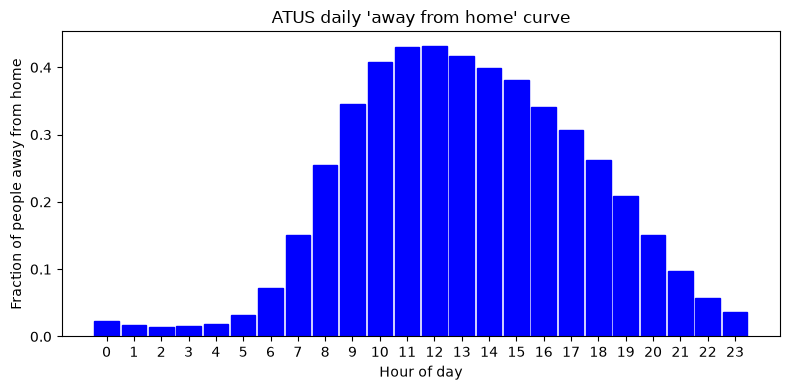

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hours, frac_away_hour, width=0.9, color="blue", edgecolor="blue")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraction of people away from home")
ax.set_title("ATUS daily 'away from home' curve")
ax.set_xticks(hours)
plt.tight_layout()
plt.show()


## 4. Deriving actual hourly leaving rates

For each hour, the leaving rate is estimated directly from the activity diary:

$$
\text{home-to-floor rate}_h =
\frac{\text{weighted home-to-away transitions in hour }h}
{\text{weighted home person-hours in hour }h}.
$$

The return rate uses the analogous away-to-home transition count and away
person-hours. These are empirical continuous-time hazards in events per
person-hour; they are not scaled to a fixed daily average rate.

In [24]:
# Empirical continuous-time movement rates in events per person-hour.
# These are calculated from observed transitions and person-hours in cell 3.
leave_intensity_hourly = (
    home_to_floor_rate_hourly / home_to_floor_rate_hourly.max()
)
leave_prob_hourly = 1.0 - np.exp(-home_to_floor_rate_hourly)

print(
    f"Home-to-floor rates: {home_to_floor_rate_hourly.min():.5f} to "
    f"{home_to_floor_rate_hourly.max():.5f} events/person-hour"
)
print(
    f"Floor-to-home rates: {floor_to_home_rate_hourly.min():.5f} to "
    f"{floor_to_home_rate_hourly.max():.5f} events/person-hour"
)

for hour in hours:
    print(
        f"Hour {hour:02d}: home-to-floor={home_to_floor_rate_hourly[hour]:.8f}, "
        f"floor-to-home={floor_to_home_rate_hourly[hour]:.8f}"
    )

Home-to-floor rates: 0.00099 to 0.16867 events/person-hour
Floor-to-home rates: 0.12567 to 0.67117 events/person-hour
Hour 00: home-to-floor=0.00116545, floor-to-home=0.42527631
Hour 01: home-to-floor=0.00099296, floor-to-home=0.31239831
Hour 02: home-to-floor=0.00181492, floor-to-home=0.24960380
Hour 03: home-to-floor=0.00644245, floor-to-home=0.19693654
Hour 04: home-to-floor=0.01339250, floor-to-home=0.27771349
Hour 05: home-to-floor=0.02323028, floor-to-home=0.14891960
Hour 06: home-to-floor=0.05822235, floor-to-home=0.12567012
Hour 07: home-to-floor=0.11875932, floor-to-home=0.18013447
Hour 08: home-to-floor=0.15677869, floor-to-home=0.15036883
Hour 09: home-to-floor=0.16403208, floor-to-home=0.13157797
Hour 10: home-to-floor=0.16867253, floor-to-home=0.13683278
Hour 11: home-to-floor=0.14413139, floor-to-home=0.16932855
Hour 12: home-to-floor=0.14556055, floor-to-home=0.21431783
Hour 13: home-to-floor=0.12391643, floor-to-home=0.20561922
Hour 14: home-to-floor=0.11261342, floor-t

## 5. Exporting the hourly rate table

Save the empirical hourly movement rates so the main simulation can use the
same ATUS-derived lookup table without reprocessing the activity file. The
`leave_probability` column is the probability of leaving during one hour
implied by the continuous-time leaving rate.

In [25]:
leave_prob_table = pd.DataFrame({
    "hour": hours,
    "fraction_away": frac_away_hour,
    "leave_intensity": leave_intensity_hourly,
    "leave_probability": leave_prob_hourly,
    "home_to_floor_rate": home_to_floor_rate_hourly,
    "floor_to_home_rate": floor_to_home_rate_hourly,
})
leave_prob_table.to_csv("sun_clock_leave_probability.csv", index=False)
leave_prob_table

,hour,fraction_away,leave_intensity,leave_probability,home_to_floor_rate,floor_to_home_rate
0,0,0.022577,0.006910,0.001165,0.001165,0.425276
1,1,0.016669,0.005887,0.000992,0.000993,0.312398
2,2,0.013691,0.010760,0.001813,0.001815,0.249604
3,3,0.014874,0.038195,0.006422,0.006442,0.196937
4,4,0.019049,0.079399,0.013303,0.013392,0.277713
5,5,0.032478,0.137724,0.022963,0.023230,0.148920
6,6,0.072482,0.345180,0.056560,0.058222,0.125670
7,7,0.150604,0.704082,0.111979,0.118759,0.180134
8,8,0.255051,0.929486,0.145107,0.156779,0.150369
9,9,0.345928,0.972488,0.151285,0.164032,0.131578
